# NB07 — EDA Sau Xử Lý

**DS108 · Nhóm:** La Gia Hân (24520448) · Huỳnh Gia Hào (24520457)

**Input chính:** `data/processed/unified_v1_merged.csv` (chưa scale — dùng cho biểu đồ có đơn vị thực)  
**Input phụ:** `data/processed/final_v1_dataset.csv` (đã scale — dùng cho correlation heatmap)  
**Output:** `reports/eda_after/` (biểu đồ) · `reports/eda_report.md` (tổng hợp)

**Bài toán:** STLF — Dự báo phụ tải ngắn hạn 1–24 giờ cho 3 miền Bắc–Trung–Nam  
**Target:** Load_North, Load_Central, Load_South (3 model độc lập)  
**Price:** Phân tích độc lập — **KHÔNG dùng làm feature** (data leakage)


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# REPO_ROOT: đi lên 1 cấp nếu đang chạy từ notebooks/
REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

# Paths
PROCESSED_DIR = Path('data/processed')
REPORT_DIR    = Path('reports/eda_after')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

assert PROCESSED_DIR.exists(), '[ERROR] Chưa chạy NB01-NB06: data/processed/ không tồn tại'

# Matplotlib style
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'font.size':         11,
})
sns.set_theme(style='whitegrid')

# Đọc dữ liệu
df = pd.read_csv(
    PROCESSED_DIR / 'unified_v1_merged.csv',
    encoding='utf-8-sig',
    parse_dates=['Timestamp'],
)
df = df.set_index('Timestamp').sort_index()
# Drop dòng thừa ngoài mốc pipeline
df = df[df.index <= '2026-03-10 23:30:00']

df_final = pd.read_csv(
    PROCESSED_DIR / 'final_v1_dataset.csv',
    encoding='utf-8-sig',
    parse_dates=['Timestamp'],
)
df_final = df_final.set_index('Timestamp').sort_index()

df_raw = pd.read_csv(
    PROCESSED_DIR / 'nsmo_raw_merged.csv',
    encoding='utf-8-sig',
    parse_dates=['Timestamp'],
)
df_raw = df_raw.set_index('Timestamp').sort_index()

# Constants
LAG_1   = 1
LAG_48  = 48
LAG_336 = 336

LOAD_COLS  = ['Load_North', 'Load_Central', 'Load_South', 'Load_National']
PRICE_COLS = ['Price_North', 'Price_Central', 'Price_South', 'Price_National']
REGION_MAP = {'North': 'Mien Bac', 'Central': 'Mien Trung', 'South': 'Mien Nam'}
COLORS_3   = ['#1f77b4', '#ff7f0e', '#2ca02c']

print(f'[OK] Working directory: {os.getcwd()}')
print(f'[OK] unified_v1_merged : {df.shape[0]:,} dong x {df.shape[1]} cot')
print(f'[OK] final_v1_dataset  : {df_final.shape[0]:,} dong x {df_final.shape[1]} cot')
print(f'     Moc bat dau : {df.index.min()}')
print(f'     Moc ket thuc: {df.index.max()}')


[OK] Working directory: c:\Users\ASUS\DS108-Project
[OK] unified_v1_merged : 52,607 dong x 41 cot
[OK] final_v1_dataset  : 52,272 dong x 63 cot
     Moc bat dau : 2023-03-11 00:30:00
     Moc ket thuc: 2026-03-10 23:30:00


In [2]:
# Kiểm tra dòng thừa so với mốc pipeline
expected_unified = pd.date_range(
    start='2023-03-11 00:30', end='2026-03-10 23:30', freq='30min'
)
expected_final = pd.date_range(
    start='2023-03-18 00:30', end='2026-03-10 23:30', freq='30min'
)

gap_unified = len(expected_unified) - len(df)
gap_final   = len(expected_final)   - len(df_final)
extra       = df.index.difference(expected_unified)

print(f'unified : {len(df):,} dong (ly thuyet {len(expected_unified):,}, gap = {gap_unified})')
print(f'final   : {len(df_final):,} dong (ly thuyet {len(expected_final):,}, gap = {gap_final})')

if len(extra) > 0:
    print(f'[WARNING] Dong thua: {list(extra)}')
else:
    print('[OK] Khong co dong thua ngoai moc pipeline')


unified : 52,607 dong (ly thuyet 52,607, gap = 0)
final   : 52,272 dong (ly thuyet 52,271, gap = -1)
[OK] Khong co dong thua ngoai moc pipeline


---
## 1. Thống Kê Mô Tả Tổng Quan

Phần này cung cấp số liệu nền và so sánh định lượng trước/sau xử lý —  
trả lời yêu cầu "EDA có số liệu định lượng" của giảng viên.


### 1.1 Thống kê Load

In [3]:
# 1. Khởi tạo bảng thống kê mô tả và chuyển vị (T)
load_stats = df[LOAD_COLS].describe().T.copy()

# 2. Tính toán thêm các chỉ số mới (Hết lỗi nhờ xuống dòng)
load_stats['cv%']  = (load_stats['std'] / load_stats['mean'] * 100).round(2)
load_stats['iqr']  = (df[LOAD_COLS].quantile(0.75) - df[LOAD_COLS].quantile(0.25)).values
load_stats['skew'] = df[LOAD_COLS].skew().values

# 3. Lọc các cột cần hiển thị và in kết quả
display_cols = ['mean', '50%', 'std', 'cv%', 'min', 'max', 'iqr', 'skew']
print("=== Thống kê Load (MW) ===")
print(load_stats[display_cols].round(2).to_string())

=== Thống kê Load (MW) ===
                   mean       50%      std    cv%  min       max      iqr  skew
Load_North     16589.55  16566.60  3144.57  18.96  0.0  29048.42  4219.00  0.05
Load_Central    3473.34   3471.40   653.27  18.81  0.0   7871.79   919.61  0.08
Load_South     15276.49  15331.92  2577.89  16.87  0.0  22670.70  3785.00 -0.29
Load_National  35339.24  35596.60  5759.11  16.30  0.0  55580.70  8340.55 -0.24


**Nhận xét:**
- **Mean vs Median (50%):** Nếu gần nhau → phân phối đối xứng; nếu lệch → ảnh hưởng của tính mùa vụ.
- **CV% (Coefficient of Variation):** Cho biết miền nào dao động tương đối nhiều nhất so với mức trung bình.  
  Miền Trung thường có CV cao hơn vì quy mô nhỏ nhưng biên độ dao động không nhỏ hơn tỷ lệ thuận.
- **IQR:** Biên độ "thông thường" trong MW — 50% số chu kỳ nằm trong khoảng này.
- **Skewness:** Giá trị dương → phân phối lệch phải (có các điểm phụ tải rất cao trong mùa hè).


### 1.2 Thống kê Price

In [4]:
# 1. Khởi tạo bảng thống kê
price_stats = df[PRICE_COLS].describe().T.copy()

# 2. Tính toán thêm các chỉ số (Đã bỏ .values để an toàn hơn)
price_stats['zero_rate%'] = ((df[PRICE_COLS] == 0).mean() * 100)
price_stats['spike_rate%'] = ((df[PRICE_COLS] > 3000).mean() * 100)
price_stats['skew'] = df[PRICE_COLS].skew()

# 3. Hiển thị kết quả
display_p = ['mean', '50%', 'std', 'min', 'max', 'zero_rate%', 'spike_rate%', 'skew']
print("=== Thống kê Price (đ/kWh) ===")
print(price_stats[display_p].round(2).to_string())

=== Thống kê Price (đ/kWh) ===
                  mean     50%     std  min     max  zero_rate%  spike_rate%  skew
Price_North     726.96  870.81  727.35  0.0  1778.6       39.79          0.0  0.19
Price_Central   499.21    0.95  655.25  0.0  1778.6       49.12          0.0  0.76
Price_South     583.40    1.00  671.07  0.0  1778.6       39.35          0.0  0.50
Price_National  835.65  968.24  710.85  0.0  1778.6       28.41          0.0 -0.09


**Nhận xét:**
- **zero_rate%:** Tỉ lệ chu kỳ có Price = 0 (thừa công suất — hợp lệ trong thị trường điện VCGM).
- **spike_rate%:** Tỉ lệ chu kỳ Price > 3,000 đ/kWh — dấu hiệu căng thẳng hệ thống.
- **Mean >> Median:** Phân phối lệch phải mạnh (skew lớn) → **justify dùng Z-score thay Min-Max** cho cột Price  
  (Min-Max sẽ bị kéo dài bởi spike, mất khả năng phân biệt phần lớn dữ liệu nằm ở vùng thấp).


### 1.3 So sánh trước/sau xử lý — bảng định lượng

In [5]:
# 1. Tạo DataFrame so sánh trước và sau khi xử lý dữ liệu thiếu
comparison = pd.DataFrame({
    'missing_before': df_raw[LOAD_COLS].isna().sum(),
    'missing_after':  df[LOAD_COLS].isna().sum(),
    'mean_before':    df_raw[LOAD_COLS].mean().round(2),
    'mean_after':     df[LOAD_COLS].mean().round(2),
    'std_before':     df_raw[LOAD_COLS].std().round(2),
    'std_after':      df[LOAD_COLS].std().round(2)
})

# 2. Tính tỷ lệ thay đổi (Delta) của Mean và Std
comparison['delta_mean%'] = ((comparison['mean_after'] - comparison['mean_before']) / comparison['mean_before'] * 100).round(3)
comparison['delta_std%']  = ((comparison['std_after'] - comparison['std_before']) / comparison['std_before'] * 100).round(3)

# 3. Hiển thị kết quả so sánh
print("=== So sánh NSMO trước/sau xử lý ===")
print(comparison.to_string())
print()
print("→ delta_mean% và delta_std% nhỏ cho thấy imputation không làm lệch phân phối đáng kể.")

=== So sánh NSMO trước/sau xử lý ===
               missing_before  missing_after  mean_before  mean_after  std_before  std_after  delta_mean%  delta_std%
Load_North                  0              0     16589.50    16589.55     3144.56    3144.57        0.000       0.000
Load_Central                0              0      3473.32     3473.34      653.27     653.27        0.001       0.000
Load_South                  0              0     15276.50    15276.49     2577.86    2577.89       -0.000       0.001
Load_National               0              0     35339.19    35339.24     5759.07    5759.11        0.000       0.001

→ delta_mean% và delta_std% nhỏ cho thấy imputation không làm lệch phân phối đáng kể.


**Nhận xét:**
- Missing = 0 sau xử lý → quá trình imputation hoàn tất.
- `delta_mean%` và `delta_std%` nhỏ → imputation bằng median không làm lệch phân phối đáng kể,  
  xác nhận lựa chọn kỹ thuật phù hợp.


---
## 2. Univariate — Phân Phối Load & Price

Mục tiêu: hiểu hình dạng phân phối của target variables trước khi phân tích sâu.


### 2.1 Histogram Load 4 miền

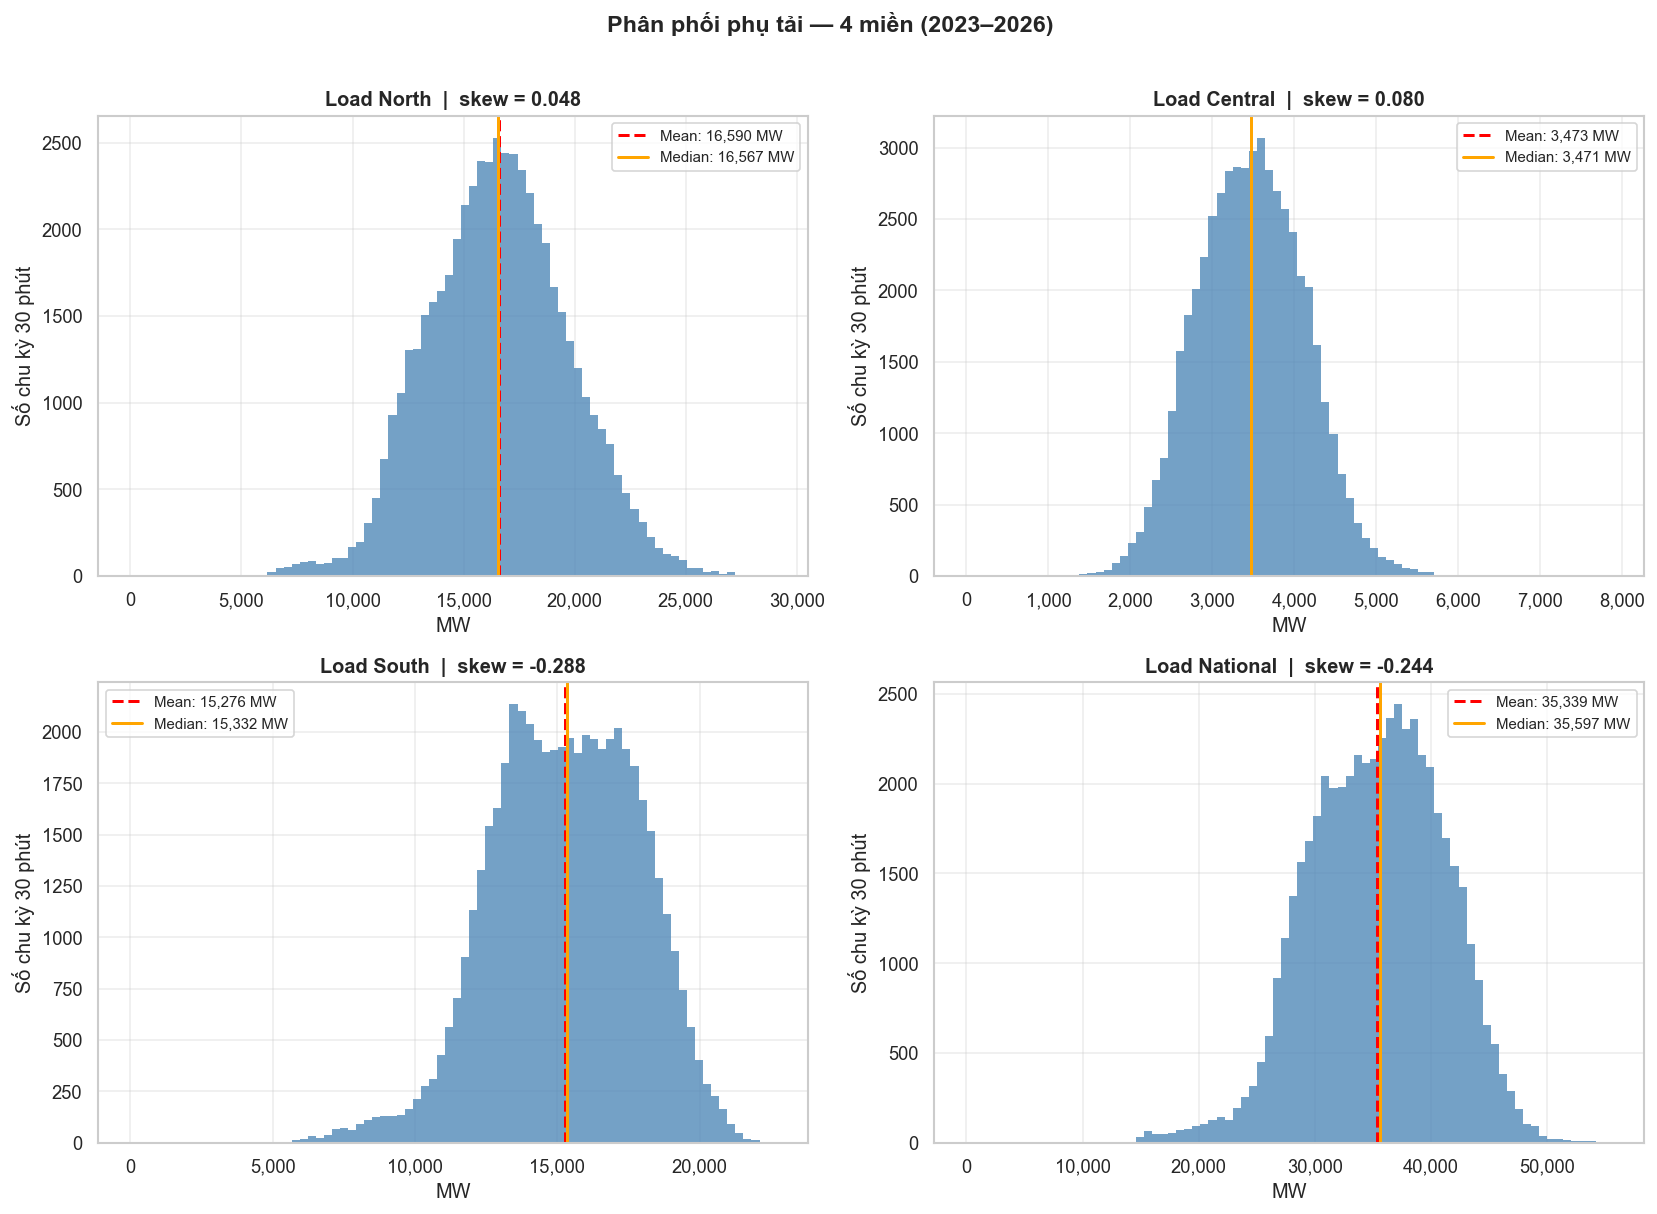

In [6]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

# 1. Khởi tạo canvas 2x2 cho 4 miền
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
skew_vals = df[LOAD_COLS].skew()

# 2. Vòng lặp vẽ histogram cho từng miền (Đã làm sạch khoảng trắng thụt lề)
for i, col in enumerate(LOAD_COLS):
    ax = axes[i]
    data = df[col].dropna()
    
    # Vẽ biểu đồ phân phối
    ax.hist(data, bins=80, color='steelblue', alpha=0.75, edgecolor='none')
    
    # Vẽ đường Mean và Median
    ax.axvline(data.mean(), color='red', lw=1.8, ls='--', label=f'Mean: {data.mean():,.0f} MW')
    ax.axvline(data.median(), color='orange', lw=1.8, ls='-', label=f'Median: {data.median():,.0f} MW')
    
    # Cấu hình title, label và legend
    ax.set_title(
        f'{col.replace("_", " ")}  |  skew = {skew_vals[col]:.3f}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('MW')
    ax.set_ylabel('Số chu kỳ 30 phút')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Định dạng tổng thể, lưu file và hiển thị
plt.suptitle('Phân phối phụ tải — 4 miền (2023–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'hist_load.png'), dpi=150, bbox_inches='tight')
plt.show()
# Saved: reports/eda_after/hist_load.png

**Nhận xét:**
- Quan sát dạng phân phối: có bimodal (2 đỉnh) hay không?  
  Nếu có → phản ánh rõ sự phân tách giữa giờ thấp điểm và giờ cao điểm trong ngày.
- **Skewness:** Dương → phân phối có đuôi phải dài hơn (các giờ phụ tải đỉnh mùa hè).  
  Giá trị skewness gần 0 hơn ở Load_National vì hiệu ứng trung bình hoá 3 miền.
- **Load_Central:** Biên độ hẹp hơn 2 miền còn lại (quy mô phụ tải miền Trung nhỏ hơn).


### 2.2 Histogram Price 4 miền (loại trừ Price = 0)

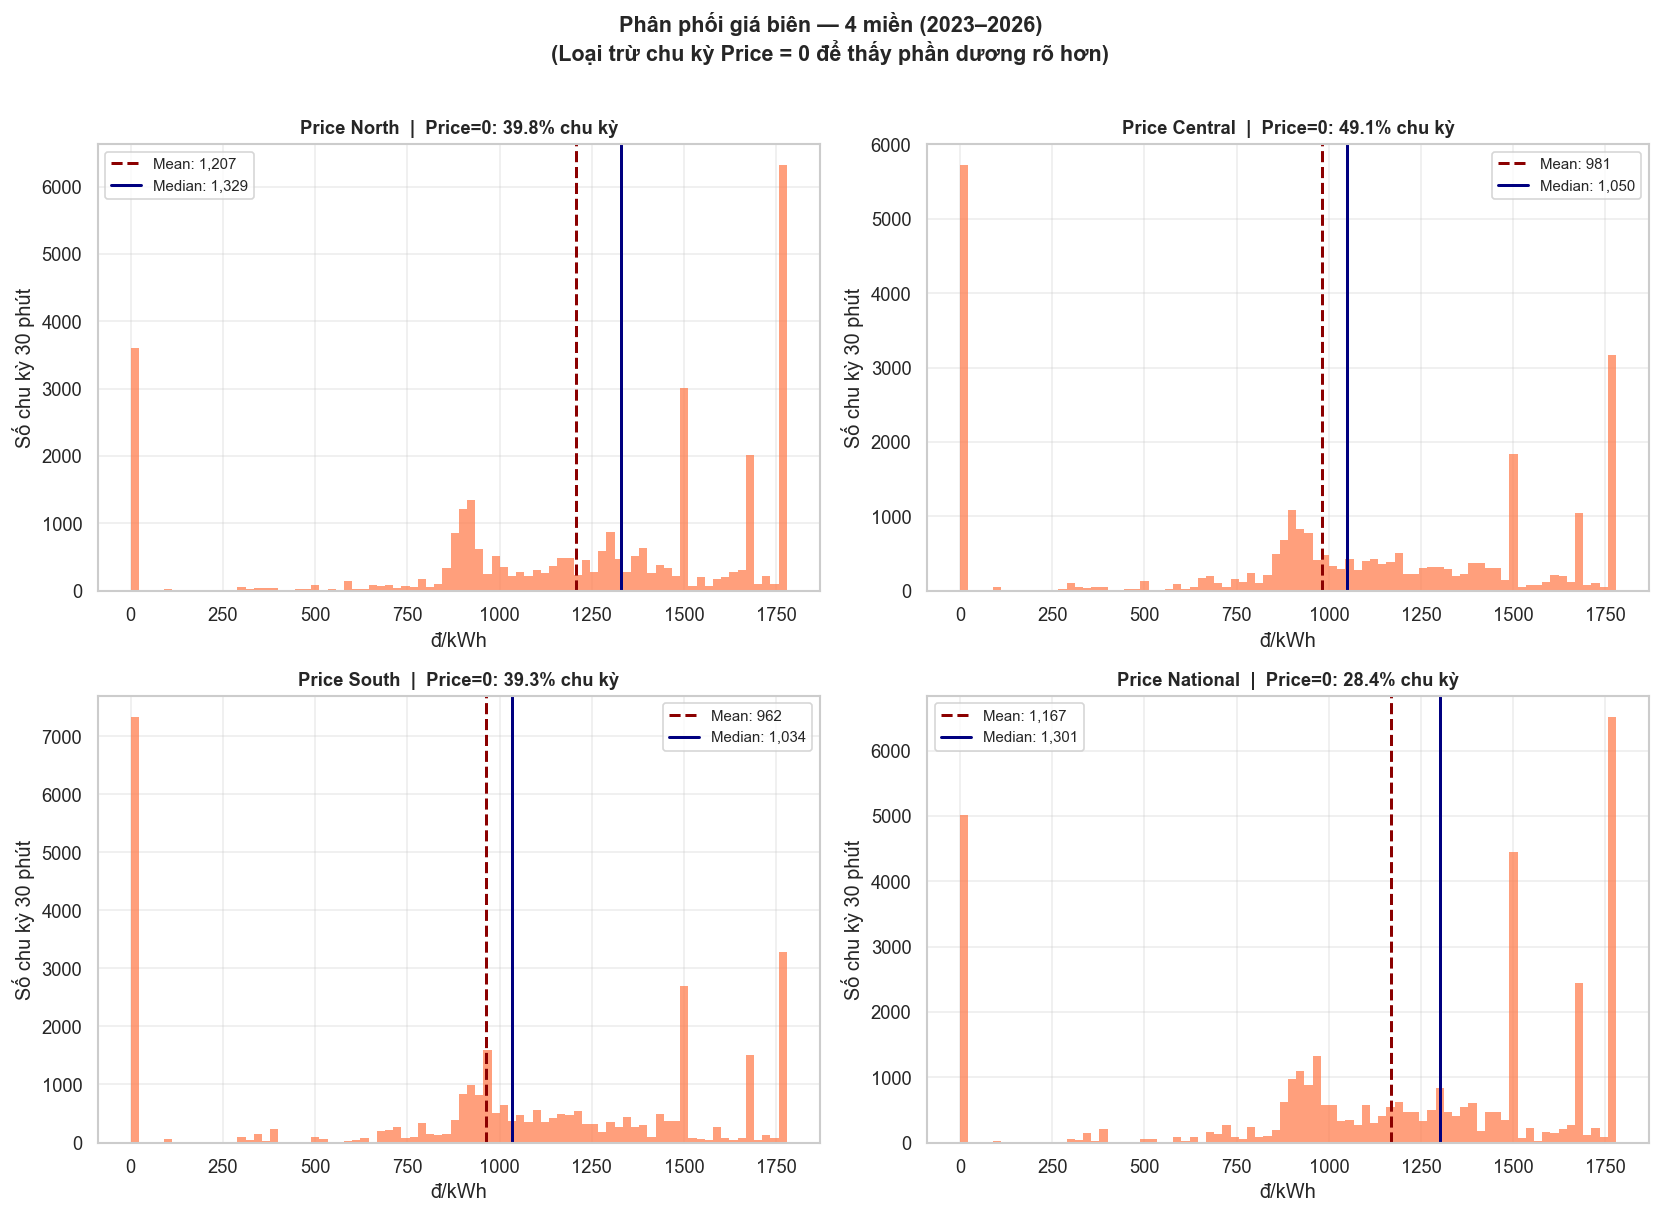

Saved: reports/eda_after/hist_price.png


In [7]:
import matplotlib.pyplot as plt

# 1. Khởi tạo canvas 2x2 cho 4 miền giá
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 2. Vòng lặp vẽ biểu đồ phân phối giá
for i, col in enumerate(PRICE_COLS):
    ax = axes[i]
    zero_pct = (df[col] == 0).mean() * 100
    data_nonzero = df[col][df[col] > 0].dropna()
    
    # Vẽ histogram cho các chu kỳ giá dương
    ax.hist(data_nonzero, bins=80, color='coral', alpha=0.75, edgecolor='none')
    
    # Vẽ đường Mean và Median
    ax.axvline(data_nonzero.mean(), color='darkred', lw=1.8, ls='--', label=f'Mean: {data_nonzero.mean():,.0f}')
    ax.axvline(data_nonzero.median(), color='navy', lw=1.8, ls='-', label=f'Median: {data_nonzero.median():,.0f}')
    
    # Cấu hình nhãn và tiêu đề từng hình nhỏ
    ax.set_title(
        f'{col.replace("_"," ")}  |  Price=0: {zero_pct:.1f}% chu kỳ',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('đ/kWh')
    ax.set_ylabel('Số chu kỳ 30 phút')
    ax.legend(fontsize=9)

# 3. Cấu hình tiêu đề tổng (Đã sửa lỗi nối chuỗi), lưu file và hiển thị
title_text = 'Phân phối giá biên — 4 miền (2023–2026)\n(Loại trừ chu kỳ Price = 0 để thấy phần dương rõ hơn)'
plt.suptitle(title_text, fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'hist_price.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Saved: reports/eda_after/hist_price.png")

**Nhận xét:**
- **Price lệch phải mạnh:** Mean >> Median ở cả 4 miền → đây là lý do kỹ thuật dùng **Z-score** (không phải Min-Max)  
  khi scaling Price. Min-Max sẽ bị kéo dài bởi các spike hiếm gặp, làm mất khả năng phân biệt phần lớn dữ liệu.
- **Tỉ lệ Price = 0** hiển thị trên tiêu đề từng ô — cho biết tần suất thừa công suất mỗi miền.
- **Price spike > 3,000 đ/kWh:** Xem thêm ở Phần 5.2 (phân tích theo thời gian).


---
## 3. Bivariate — Tương Quan Feature–Target

Mục tiêu: chứng minh các feature đã chọn có mối quan hệ thực sự với Load,  
justify toàn bộ pipeline feature engineering.


### 3.1 Scatter Load vs Temperature — chứng minh phi tuyến

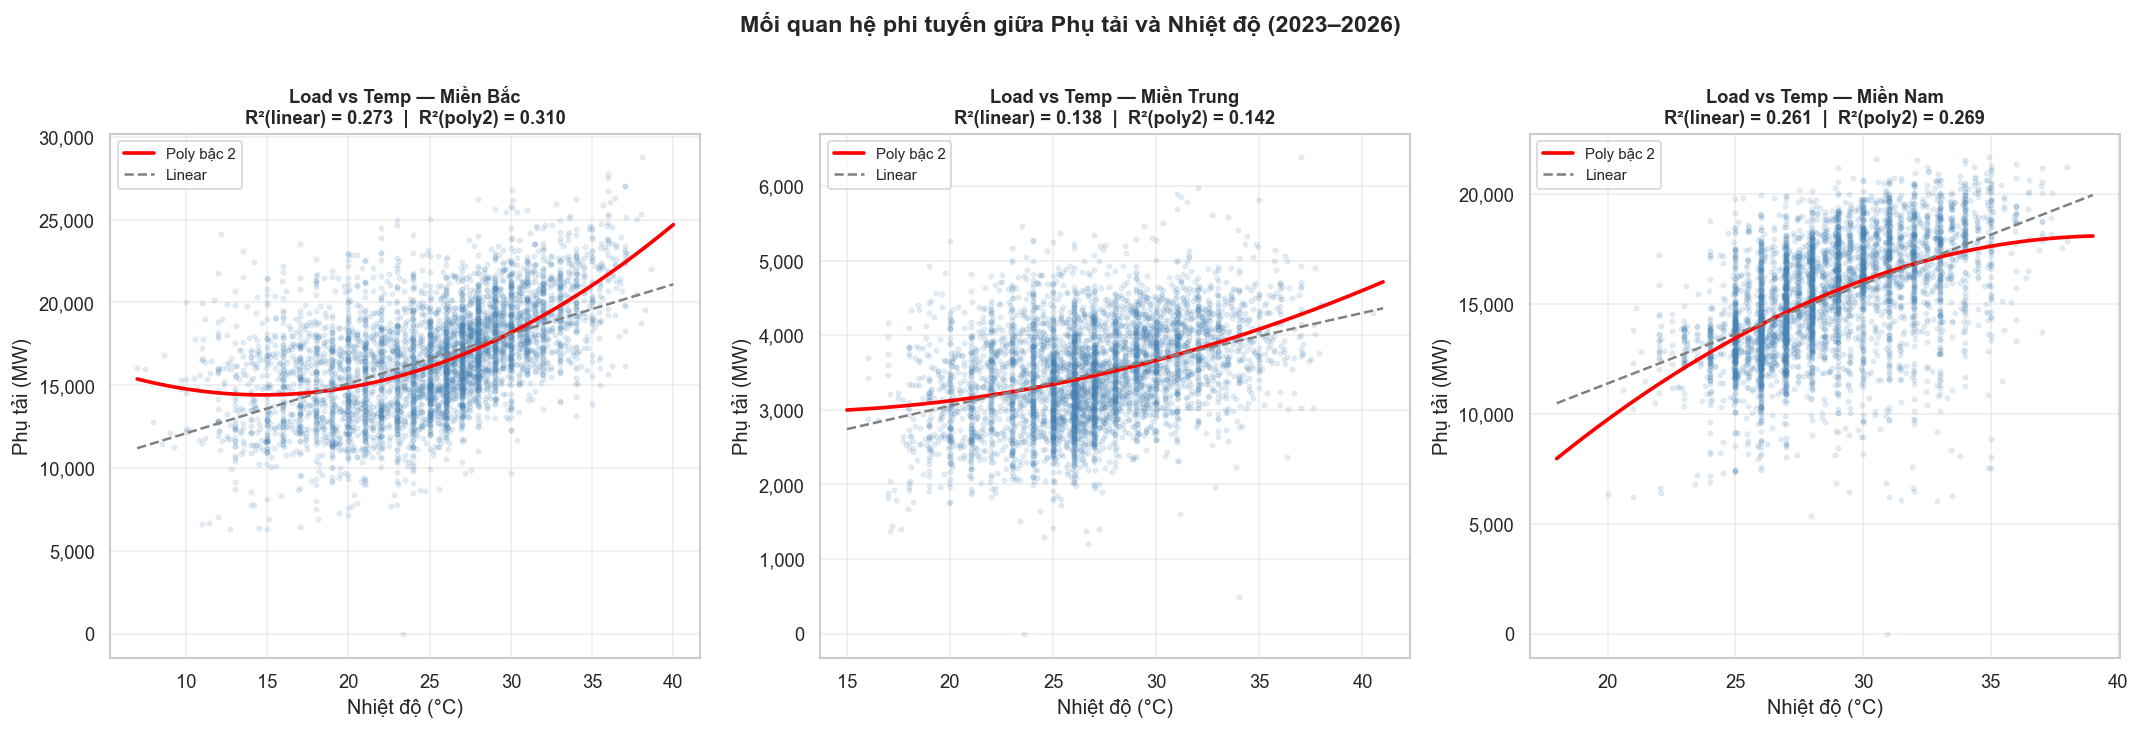

Saved: reports/eda_after/scatter_load_temp.png

=== R² Summary ===
Miền Bắc    : R²(linear)=0.273  R²(poly2)=0.310  (+13.4% cải thiện)
Miền Trung  : R²(linear)=0.138  R²(poly2)=0.142  (+2.7% cải thiện)
Miền Nam    : R²(linear)=0.261  R²(poly2)=0.269  (+2.9% cải thiện)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Khai báo REGION_MAP để tránh lỗi NameError nếu chưa định nghĩa phía trên
REGION_MAP = {'North': 'Miền Bắc', 'Central': 'Miền Trung', 'South': 'Miền Nam'}

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regions = ['North', 'Central', 'South']
r2_results = {}

for i, region in enumerate(regions):
    ax = axes[i]
    x_all = df[f'temp_{region}'].dropna()
    y_all = df[f'Load_{region}'].dropna()
    idx = x_all.index.intersection(y_all.index)
    x_all, y_all = x_all[idx], y_all[idx]
    
    # Sample để vẽ scatter không bị nặng máy
    n_sample = min(5_000, len(x_all))
    sample = np.random.choice(len(x_all), size=n_sample, replace=False)
    ax.scatter(x_all.iloc[sample], y_all.iloc[sample], alpha=0.12, s=7, color='steelblue')
    
    # Fit polynomial bậc 2 và bậc 1 (dùng toàn bộ data)
    x_np, y_np = x_all.values, y_all.values
    coef2 = np.polyfit(x_np, y_np, 2)
    coef1 = np.polyfit(x_np, y_np, 1)
    p2 = np.poly1d(coef2)
    p1 = np.poly1d(coef1)
    
    x_range = np.linspace(x_np.min(), x_np.max(), 300)
    ax.plot(x_range, p2(x_range), color='red', lw=2.2, label='Poly bậc 2')
    ax.plot(x_range, p1(x_range), color='grey', lw=1.5, ls='--', label='Linear')
    
    # Tính toán chỉ số R²
    ss_tot = np.sum((y_np - y_np.mean()) ** 2)
    r2_lin = 1 - np.sum((y_np - p1(x_np)) ** 2) / ss_tot
    r2_poly = 1 - np.sum((y_np - p2(x_np)) ** 2) / ss_tot
    r2_results[region] = {'r2_linear': r2_lin, 'r2_poly2': r2_poly}
    
    # Cấu hình đồ thị nhỏ
    ax.set_title(
        f'Load vs Temp — {REGION_MAP[region]}\n'
        f'R²(linear) = {r2_lin:.3f}  |  R²(poly2) = {r2_poly:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Nhiệt độ (°C)')
    ax.set_ylabel('Phụ tải (MW)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9)

# Cấu hình tiêu đề tổng, lưu file và hiển thị
plt.suptitle('Mối quan hệ phi tuyến giữa Phụ tải và Nhiệt độ (2023–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'scatter_load_temp.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Saved: reports/eda_after/scatter_load_temp.png")
print()

print("=== R² Summary ===")
for region, vals in r2_results.items():
    improvement = (vals['r2_poly2'] - vals['r2_linear']) / vals['r2_linear'] * 100
    print(f"{REGION_MAP[region]:12s}: "
          f"R²(linear)={vals['r2_linear']:.3f}  "
          f"R²(poly2)={vals['r2_poly2']:.3f}  "
          f"(+{improvement:.1f}% cải thiện)")

**Nhận xét (điểm giảng viên yêu cầu):**
- **R²(poly2) > R²(linear)** ở cả 3 miền → xác nhận tính phi tuyến Load–Temp.
- **Hình chữ U:**  
  - Nhiệt độ thấp (mùa đông, đặc biệt miền Bắc) → Load tăng do nhu cầu sưởi ấm.  
  - Nhiệt độ cao (mùa hè) → Load tăng mạnh do điều hòa không khí.  
- **Miền Nam:** Hình chữ U kém rõ hơn miền Bắc vì nhiệt độ quanh năm cao và ít biến thiên  
  → feature `temp` vẫn có giá trị nhưng cần kết hợp với `month` và `hour` để capture pattern đầy đủ.
- **Kết luận:** Tính phi tuyến justify việc không dùng Linear Regression thuần và đưa `temp` vào feature set.


### 3.2 Correlation Heatmap — Load vs Features

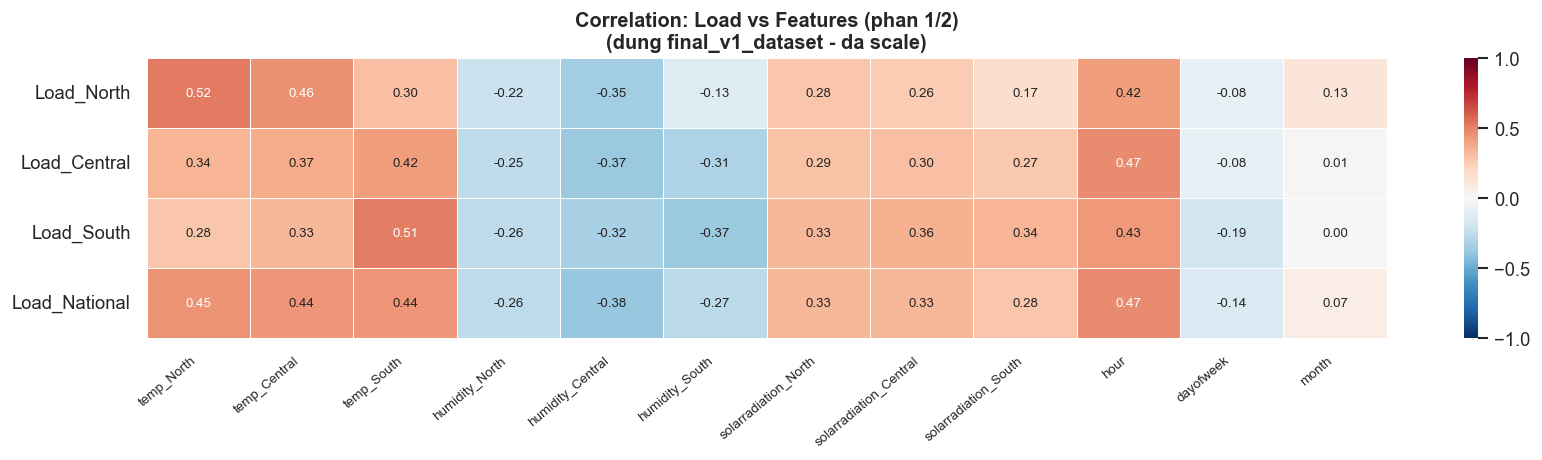

  -> Saved: heatmap_load_features_1.png


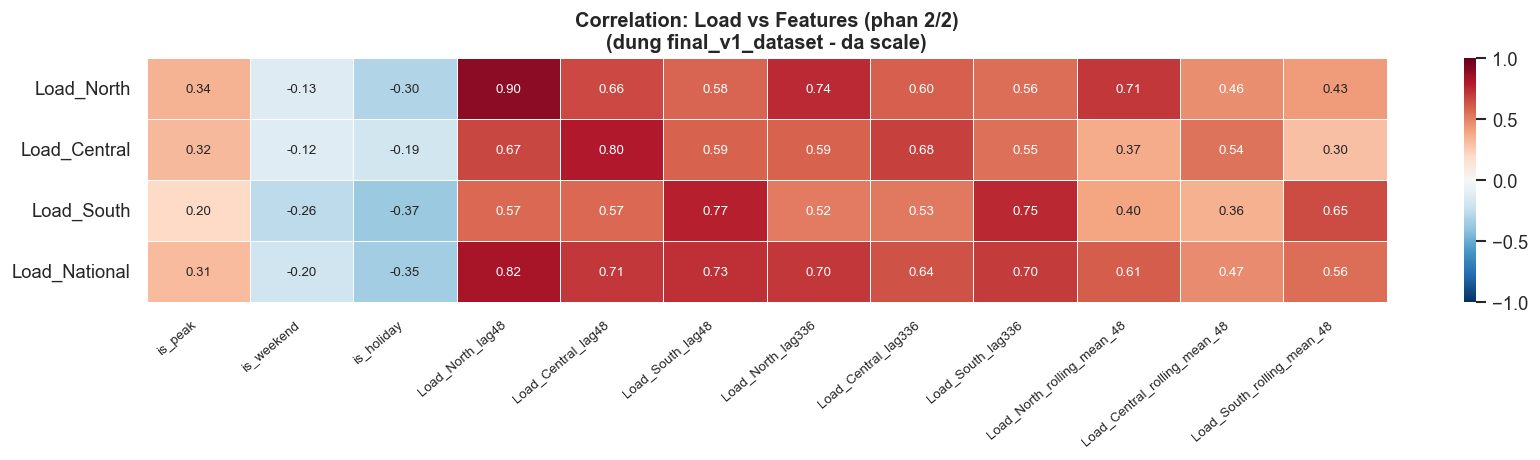

  -> Saved: heatmap_load_features_2.png

=== Top features tuong quan voi Load (|r| lon nhat) ===

Load_North:
  Load_North_lag48                        : r = +0.898
  Load_North_lag336                       : r = +0.743
  Load_North_rolling_mean_48              : r = +0.708
  Load_Central_lag48                      : r = +0.663
  Load_Central_lag336                     : r = +0.596

Load_Central:
  Load_Central_lag48                      : r = +0.801
  Load_Central_lag336                     : r = +0.683
  Load_North_lag48                        : r = +0.671
  Load_North_lag336                       : r = +0.591
  Load_South_lag48                        : r = +0.588

Load_South:
  Load_South_lag48                        : r = +0.775
  Load_South_lag336                       : r = +0.750
  Load_South_rolling_mean_48              : r = +0.651
  Load_Central_lag48                      : r = +0.574
  Load_North_lag48                        : r = +0.571

Load_National:
  Load_North_lag48   

In [9]:
lag_candidates = [
    'Load_North_lag48',   'Load_Central_lag48',   'Load_South_lag48',
    'Load_North_lag336',  'Load_Central_lag336',  'Load_South_lag336',
    'Load_North_rolling_mean_48',
    'Load_Central_rolling_mean_48',
    'Load_South_rolling_mean_48',
]

feature_cols_heat = (
    LOAD_COLS
    + [
        'temp_North',          'temp_Central',          'temp_South',
        'humidity_North',      'humidity_Central',      'humidity_South',
        'solarradiation_North','solarradiation_Central','solarradiation_South',
        'hour', 'dayofweek', 'month', 'is_peak', 'is_weekend', 'is_holiday',
    ]
    + [c for c in lag_candidates if c in df_final.columns]
)
feature_cols_heat = [c for c in feature_cols_heat if c in df_final.columns]

corr      = df_final[feature_cols_heat].corr()
feature_x = [c for c in feature_cols_heat if c not in LOAD_COLS]
load_corr = corr.loc[LOAD_COLS, feature_x]

# Chia 2 heatmap nếu nhiều feature để tránh overlap chữ
mid    = len(feature_x) // 2
groups = [feature_x[:mid], feature_x[mid:]] if len(feature_x) > 12 else [feature_x]

for g_idx, feat_group in enumerate(groups):
    fig, ax = plt.subplots(figsize=(max(14, len(feat_group) * 1.2), 4))
    sns.heatmap(
        load_corr[feat_group], annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, ax=ax, annot_kws={'size': 8},
    )
    suffix = f' (phan {g_idx + 1}/{len(groups)})' if len(groups) > 1 else ''
    ax.set_title(
        f'Correlation: Load vs Features{suffix}\n'
        f'(dung final_v1_dataset - da scale)',
        fontsize=12, fontweight='bold',
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    fname = (
        f'heatmap_load_features_{g_idx + 1}.png'
        if len(groups) > 1
        else 'heatmap_load_features.png'
    )
    plt.tight_layout()
    plt.savefig(str(REPORT_DIR / fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  -> Saved: {fname}')

print()
print('=== Top features tuong quan voi Load (|r| lon nhat) ===')
for load_col in LOAD_COLS:
    top = load_corr.loc[load_col].abs().sort_values(ascending=False).head(5)
    print(f'\n{load_col}:')
    for feat in top.index:
        print(f'  {feat:40s}: r = {load_corr.loc[load_col, feat]:+.3f}')


**Nhận xét:**
- Các feature nào có |r| cao nhất với từng Load → xác nhận feature selection hợp lý.
- Kiểm tra **multicollinearity**: cặp feature nào có |r| > 0.8 với nhau → rủi ro nếu dùng Linear Regression  
  (không ảnh hưởng Random Forest, nhưng cần ghi nhận).
- `hour` và `is_peak` thường tương quan khá cao với nhau do is_peak được định nghĩa từ hour  
  → bình thường, không phải vấn đề nghiêm trọng.


---
## 4. Time Series Patterns

Mục tiêu: justify lag features và boolean features (is_peak, is_weekend, is_holiday)  
bằng bằng chứng trực quan và số liệu cụ thể.


### 4.1 Daily Pattern — phụ tải trung bình theo giờ

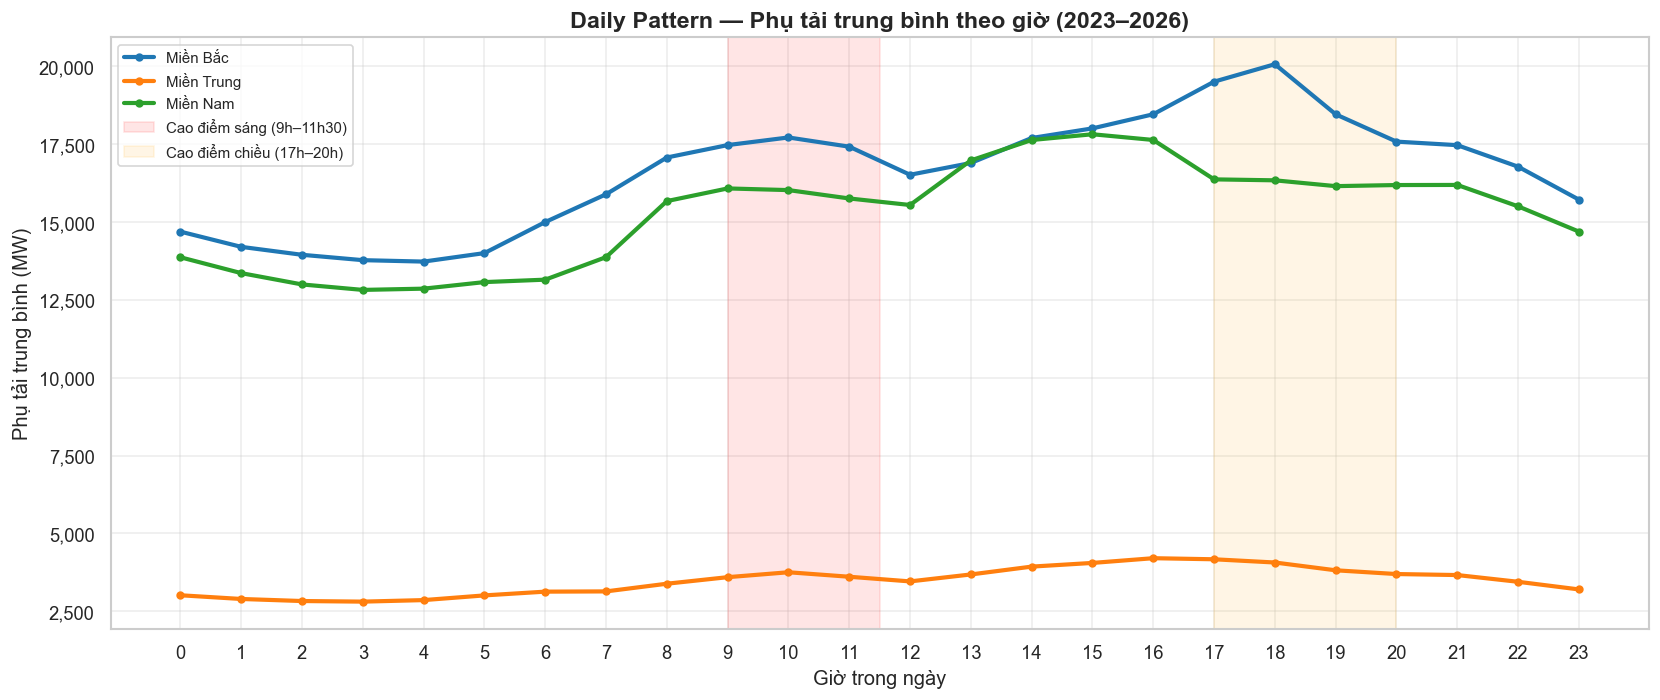

Saved: reports/eda_after/daily_pattern.png

=== Daily Pattern — Số liệu cụ thể ===
Miền Bắc    : peak 20,072 MW (giờ 18h) | trough 13,731 MW (giờ 04h) | biên độ 6,341 MW
Miền Trung  : peak 4,202 MW (giờ 16h) | trough 2,807 MW (giờ 03h) | biên độ 1,395 MW
Miền Nam    : peak 17,822 MW (giờ 15h) | trough 12,821 MW (giờ 03h) | biên độ 5,001 MW


In [10]:
df_plot = df.copy()
df_plot['hour'] = df_plot.index.hour
daily = df_plot.groupby('hour')[LOAD_COLS[:3]].mean()

fig, ax = plt.subplots(figsize=(14, 6))

for col, color, label in zip(LOAD_COLS[:3], COLORS_3, REGION_MAP.values()):
    ax.plot(
        daily.index, daily[col],
        color=color, lw=2.5, marker='o', markersize=4, label=label,
    )

# Highlight giờ cao điểm
ax.axvspan(9,  11.5, alpha=0.10, color='red',    label='Cao điểm sáng (9h–11h30)')
ax.axvspan(17, 20,   alpha=0.10, color='orange',  label='Cao điểm chiều (17h–20h)')

ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Phụ tải trung bình (MW)')
ax.set_title(
    'Daily Pattern — Phụ tải trung bình theo giờ (2023–2026)',
    fontsize=14, fontweight='bold',
)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'daily_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/eda_after/daily_pattern.png")

# Số liệu cụ thể
print()
print("=== Daily Pattern — Số liệu cụ thể ===")
for col, label in zip(LOAD_COLS[:3], REGION_MAP.values()):
    peak_hour   = daily[col].idxmax()
    trough_hour = daily[col].idxmin()
    amplitude   = daily[col].max() - daily[col].min()
    print(
        f"{label:12s}: peak {daily[col].max():,.0f} MW (giờ {peak_hour:02d}h) | "
        f"trough {daily[col].min():,.0f} MW (giờ {trough_hour:02d}h) | "
        f"biên độ {amplitude:,.0f} MW"
    )


**Nhận xét:**
- 2 đỉnh cao điểm xuất hiện rõ: sáng (~9h–11h) và chiều/tối (~17h–20h) → justify `is_peak`.
- Đáy thấp nhất vào khoảng 3h–4h sáng (điện phụ tải thấp nhất do hoạt động kinh tế ngừng).
- **Biên độ dao động** trong ngày (peak – trough): số liệu cụ thể in ở trên →  
  miền nào có biên độ lớn nhất phản ánh nhu cầu điều tiết cao hơn.
- Daily pattern ổn định và lặp lại → justify **lag t-48** (cùng giờ hôm qua là predictor tốt).
- **Kết luận:** Daily pattern rõ ràng justify feature `hour` và `is_peak`.


### 4.2 Weekly Pattern — ngày thường vs cuối tuần

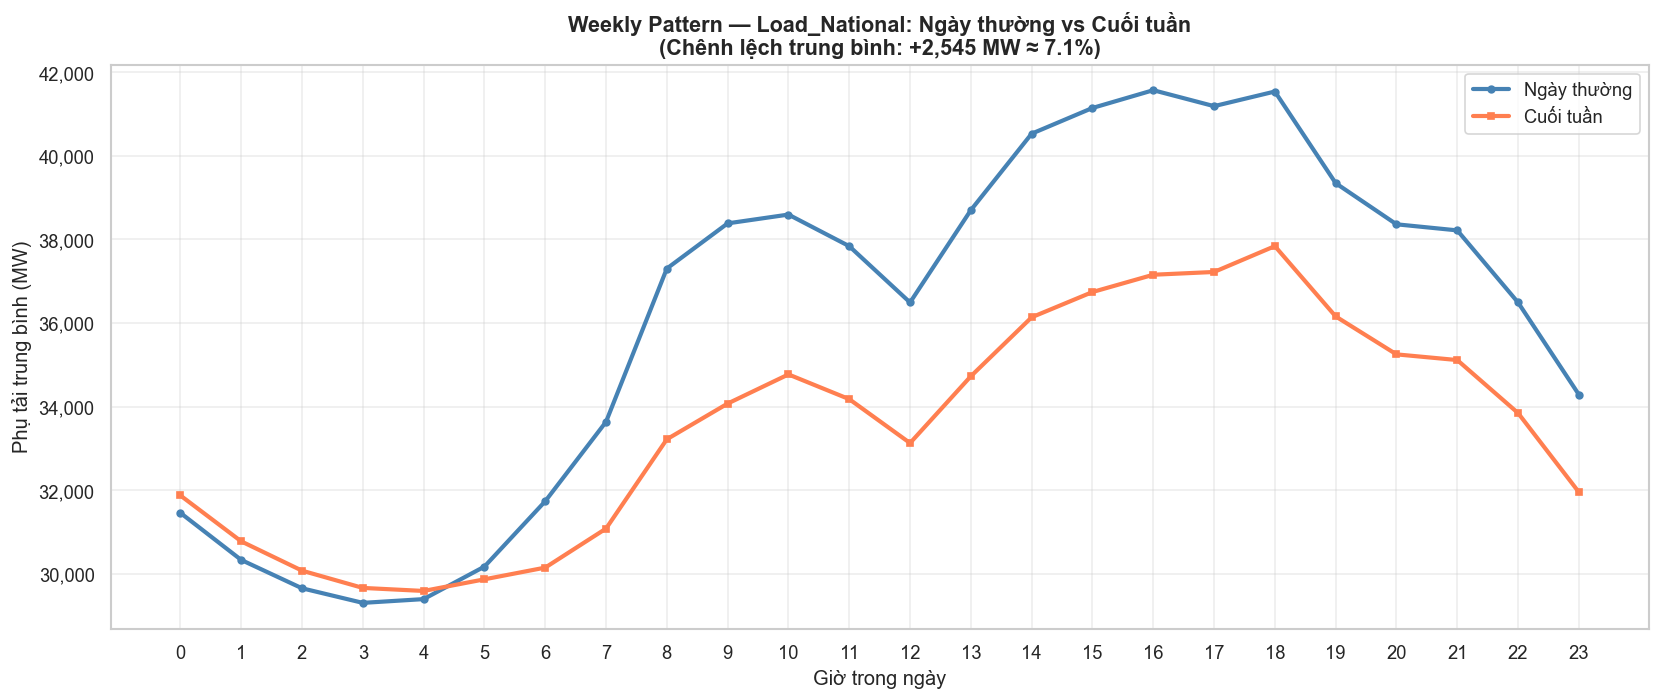

Saved: reports/eda_after/weekly_pattern.png
Đỉnh cao điểm sáng — Ngày thường: 16h | Cuối tuần: 18h (trễ 2h)


In [11]:
df_plot['dayofweek'] = df_plot.index.dayofweek
df_plot['is_weekend'] = df_plot['dayofweek'] >= 5

weekly = (
    df_plot
    .groupby(['hour', 'is_weekend'])['Load_National']
    .mean()
    .unstack()
)
weekly.columns = ['Ngày thường', 'Cuối tuần']

fig, ax = plt.subplots(figsize=(14, 6))

weekly['Ngày thường'].plot(
    ax=ax, color='steelblue', lw=2.5, marker='o', markersize=4, label='Ngày thường',
)
weekly['Cuối tuần'].plot(
    ax=ax, color='coral', lw=2.5, marker='s', markersize=4, label='Cuối tuần',
)

diff_mean = (weekly['Ngày thường'] - weekly['Cuối tuần']).mean()
diff_pct  = diff_mean / weekly['Ngày thường'].mean() * 100

ax.set_title(
    f'Weekly Pattern — Load_National: Ngày thường vs Cuối tuần\n'
    f'(Chênh lệch trung bình: {diff_mean:+,.0f} MW ≈ {diff_pct:.1f}%)',
    fontsize=13, fontweight='bold',
)
ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Phụ tải trung bình (MW)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'weekly_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/eda_after/weekly_pattern.png")

# Peak hour shift
peak_weekday = weekly['Ngày thường'].idxmax()
peak_weekend = weekly['Cuối tuần'].idxmax()
print(
    f"Đỉnh cao điểm sáng — Ngày thường: {peak_weekday}h | Cuối tuần: {peak_weekend}h "
    f"(trễ {peak_weekend - peak_weekday}h)"
)


**Nhận xét:**
- Phụ tải ngày thường cao hơn cuối tuần → công nghiệp và thương mại là thành phần đóng góp lớn.
- Đỉnh cao điểm cuối tuần thường trễ hơn ngày thường (người dùng dân sinh thức dậy muộn hơn).
- **Kết luận:** Chênh lệch có ý nghĩa thống kê → justify feature `is_weekend`.


### 4.3 Seasonal Pattern — phụ tải trung bình theo tháng

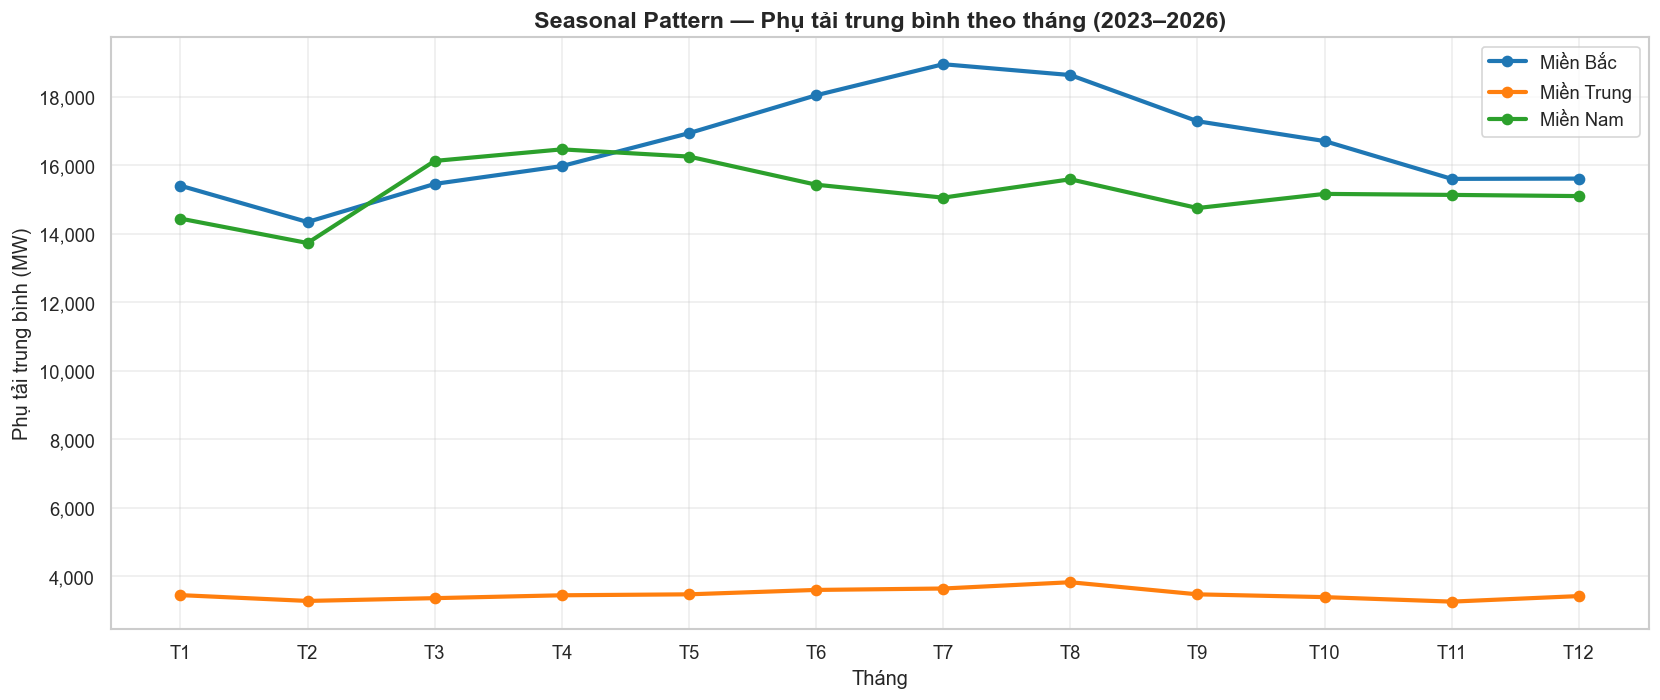

Saved: reports/eda_after/seasonal_pattern.png

=== Seasonal — Tháng peak và trough ===
Miền Bắc    : peak T7 (18,945 MW) | trough T2 (14,340 MW) | biên độ mùa vụ 4,605 MW
Miền Trung  : peak T8 (3,829 MW) | trough T11 (3,263 MW) | biên độ mùa vụ 566 MW
Miền Nam    : peak T4 (16,460 MW) | trough T2 (13,728 MW) | biên độ mùa vụ 2,732 MW


In [12]:
df_plot['month'] = df_plot.index.month
monthly = df_plot.groupby('month')[LOAD_COLS[:3]].mean()

fig, ax = plt.subplots(figsize=(14, 6))

month_labels = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6',
                'T7', 'T8', 'T9', 'T10', 'T11', 'T12']

for col, color, label in zip(LOAD_COLS[:3], COLORS_3, REGION_MAP.values()):
    ax.plot(
        monthly.index, monthly[col],
        color=color, lw=2.5, marker='o', markersize=6, label=label,
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Tháng')
ax.set_ylabel('Phụ tải trung bình (MW)')
ax.set_title(
    'Seasonal Pattern — Phụ tải trung bình theo tháng (2023–2026)',
    fontsize=14, fontweight='bold',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'seasonal_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/eda_after/seasonal_pattern.png")

print()
print("=== Seasonal — Tháng peak và trough ===")
for col, label in zip(LOAD_COLS[:3], REGION_MAP.values()):
    peak_month   = monthly[col].idxmax()
    trough_month = monthly[col].idxmin()
    seasonal_amp = monthly[col].max() - monthly[col].min()
    print(
        f"{label:12s}: peak T{peak_month} ({monthly[col].max():,.0f} MW) | "
        f"trough T{trough_month} ({monthly[col].min():,.0f} MW) | "
        f"biên độ mùa vụ {seasonal_amp:,.0f} MW"
    )


**Nhận xét:**
- **Miền Bắc:** Đỉnh tháng 6–7 (mùa hè nóng, điều hòa); có thể có đỉnh phụ tháng 12–1 (đông giá, sưởi).  
  Biên độ mùa vụ lớn nhất trong 3 miền → Bắc bị ảnh hưởng khí hậu nhiều nhất.
- **Miền Nam:** Đỉnh tháng 4–5 (nóng nhất trước mùa mưa); ít biến thiên theo mùa hơn Bắc  
  vì nhiệt độ quanh năm tương đối ổn định.
- **Miền Trung:** Pattern nằm giữa, chịu ảnh hưởng cả 2 mùa khí hậu.
- **Kết luận:** Seasonal variation rõ ràng → justify feature `month`.


### 4.4 Holiday Effect — justify is_holiday

=== Load_National theo ngày lễ / ngày thường ===
              count     mean      50%     std
is_holiday                                   
False       50303.0  35768.0  35920.0  5367.0
True         2304.0  25976.0  25580.0  6061.0


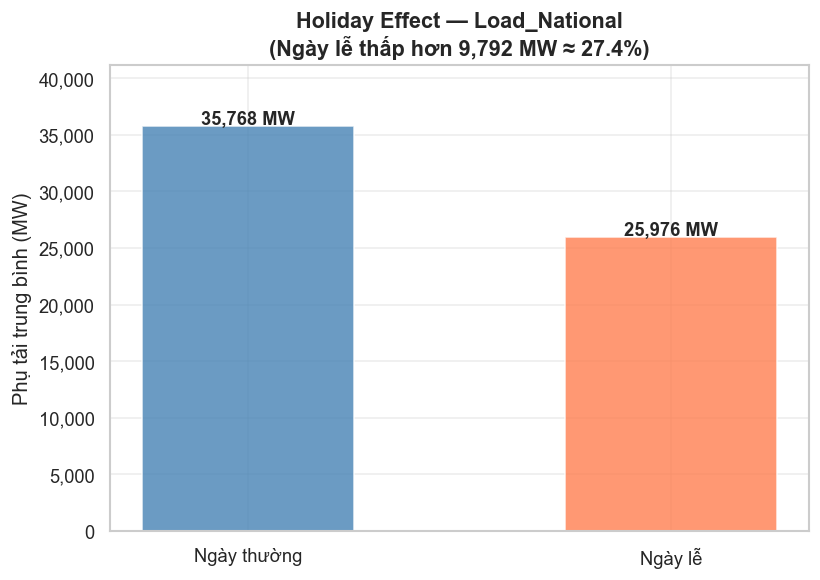

Saved: reports/eda_after/holiday_effect.png


In [13]:
# Lấy dữ liệu is_holiday từ df_final (đã được tạo ở NB06)
df_plot['is_holiday'] = df_final['is_holiday'].reindex(df_plot.index)
# Ép kiểu sang bool an toàn sau khi reindex
df_plot['is_holiday'] = df_plot['is_holiday'].astype(bool)

holiday_stats = df_plot.groupby('is_holiday')['Load_National'].describe()
print("=== Load_National theo ngày lễ / ngày thường ===")
print(holiday_stats[['count', 'mean', '50%', 'std']].round(0).to_string())

means      = df_plot.groupby('is_holiday')['Load_National'].mean()
diff_hol   = means[False] - means[True]
diff_hol_p = diff_hol / means[False] * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    ['Ngày thường', 'Ngày lễ'], means.values,
    color=['steelblue', 'coral'], alpha=0.8, width=0.5,
)
for i, v in enumerate(means.values):
    ax.text(i, v + 200, f'{v:,.0f} MW', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Phụ tải trung bình (MW)')
ax.set_title(
    f'Holiday Effect — Load_National\n'
    f'(Ngày lễ thấp hơn {diff_hol:,.0f} MW ≈ {diff_hol_p:.1f}%)',
    fontsize=13, fontweight='bold',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, means.max() * 1.15)

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'holiday_effect.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/eda_after/holiday_effect.png")


**Nhận xét:**
- Phụ tải ngày lễ thấp hơn ngày thường rõ rệt → hoạt động công nghiệp và thương mại giảm.
- **Kết luận:** Chênh lệch có ý nghĩa thực tế → justify feature `is_holiday`.


---
## 5. So Sánh 3 Miền

Mục tiêu: chứng minh 3 miền có đặc tính đủ khác nhau để cần 3 model độc lập,  
không thể gộp chung thành 1 model.


### 5.1 Boxplot Load 3 miền

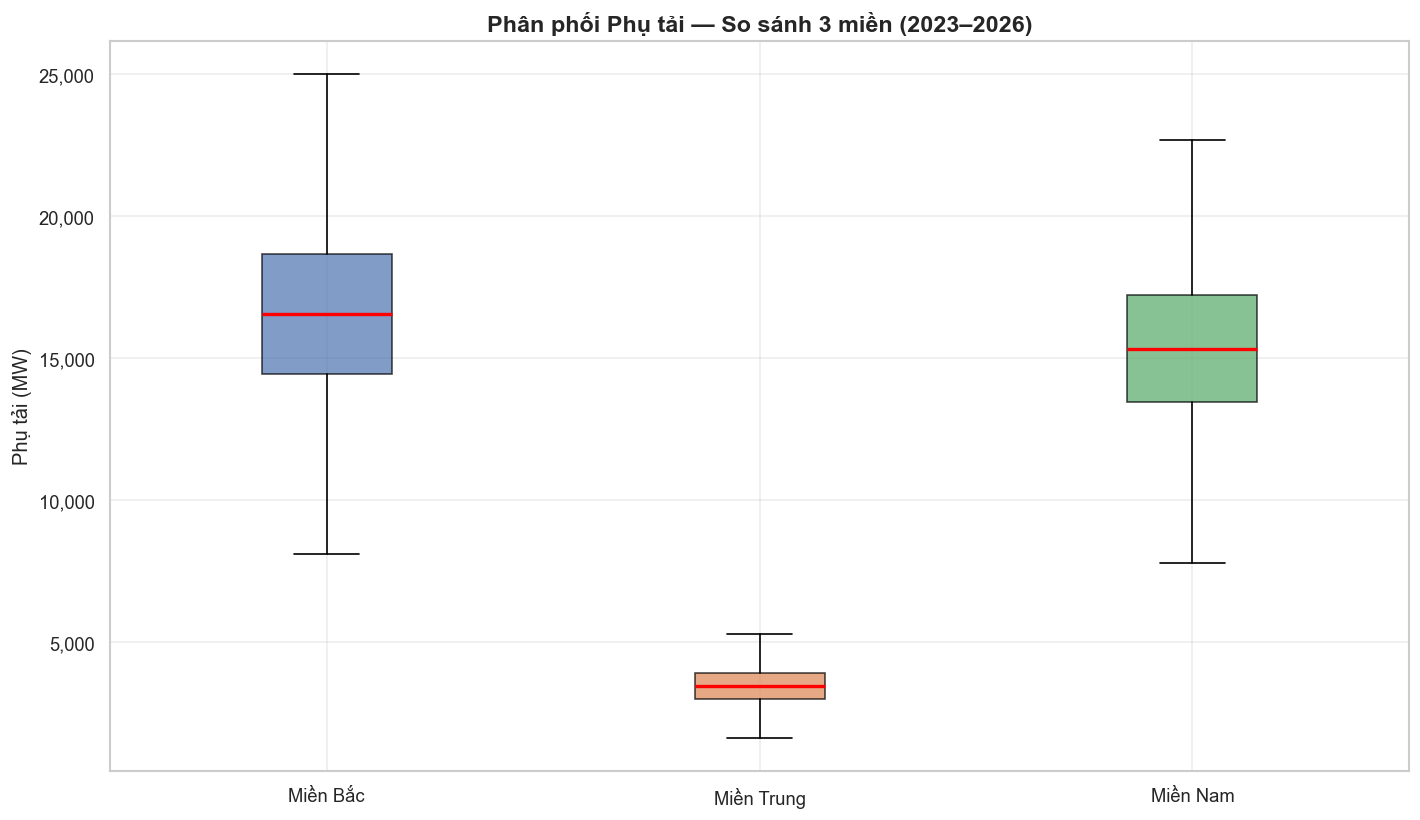

Saved: reports/eda_after/boxplot_3mien.png

=== Bảng so sánh 3 miền ===
             Miền Bắc  Miền Trung  Miền Nam
Mean (MW)     16589.5      3473.3   15276.5
Median (MW)   16566.6      3471.4   15331.9
Std (MW)       3144.6       653.3    2577.9
IQR (MW)       4219.0       919.6    3785.0
Min (MW)          0.0         0.0       0.0
Max (MW)      29048.4      7871.8   22670.7
CV%              19.0        18.8      16.9


In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

data_plot_box = [df[col].dropna() for col in LOAD_COLS[:3]]
labels_box    = list(REGION_MAP.values())

bp = ax.boxplot(
    data_plot_box, labels=labels_box,
    patch_artist=True, notch=False,
    showfliers=False,
    medianprops=dict(color='red', lw=2),
)

colors_box = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Phụ tải (MW)')
ax.set_title(
    'Phân phối Phụ tải — So sánh 3 miền (2023–2026)',
    fontsize=14, fontweight='bold',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'boxplot_3mien.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/eda_after/boxplot_3mien.png")

# Bảng số liệu tóm tắt
q1  = df[LOAD_COLS[:3]].quantile(0.25)
q3  = df[LOAD_COLS[:3]].quantile(0.75)
iqr = q3 - q1

summary = pd.DataFrame({
    'Mean (MW)':   df[LOAD_COLS[:3]].mean(),
    'Median (MW)': df[LOAD_COLS[:3]].median(),
    'Std (MW)':    df[LOAD_COLS[:3]].std(),
    'IQR (MW)':    iqr,
    'Min (MW)':    df[LOAD_COLS[:3]].min(),
    'Max (MW)':    df[LOAD_COLS[:3]].max(),
    'CV%':         df[LOAD_COLS[:3]].std() / df[LOAD_COLS[:3]].mean() * 100,
}).T

summary.columns = labels_box

print()
print("=== Bảng so sánh 3 miền ===")
print(summary.round(1).to_string())


**Nhận xét:**
- **Mean/Median:** Miền Bắc và Miền Nam có quy mô phụ tải lớn hơn Miền Trung.
- **IQR:** Miền nào có IQR lớn hơn thì biên độ dao động "thông thường" rộng hơn.
- **CV%:** So sánh mức độ biến thiên tương đối — miền có CV lớn hơn cần model linh hoạt hơn.
- **Outlier behavior:** Miền Trung có thể có nhiều flier hơn vì quy mô nhỏ nhưng thỉnh thoảng  
  spike do điện mặt trời và thủy điện miền Trung.

**Kết luận quan trọng:**  
3 miền có phân phối, biên độ, IQR, và CV khác nhau đủ lớn → **cần 3 model độc lập**  
thay vì 1 model chung (model chung sẽ bị dominated bởi miền có quy mô lớn nhất).


### 5.2 Price Analysis — Spike Timeline theo 3 miền

Price max : 1,779 d/kWh
Price p95 : 1,779 d/kWh
Price p99 : 1,779 d/kWh

  -> SPIKE_THRESHOLD tu dong: 1,779 d/kWh (p95 trung binh 3 mien)


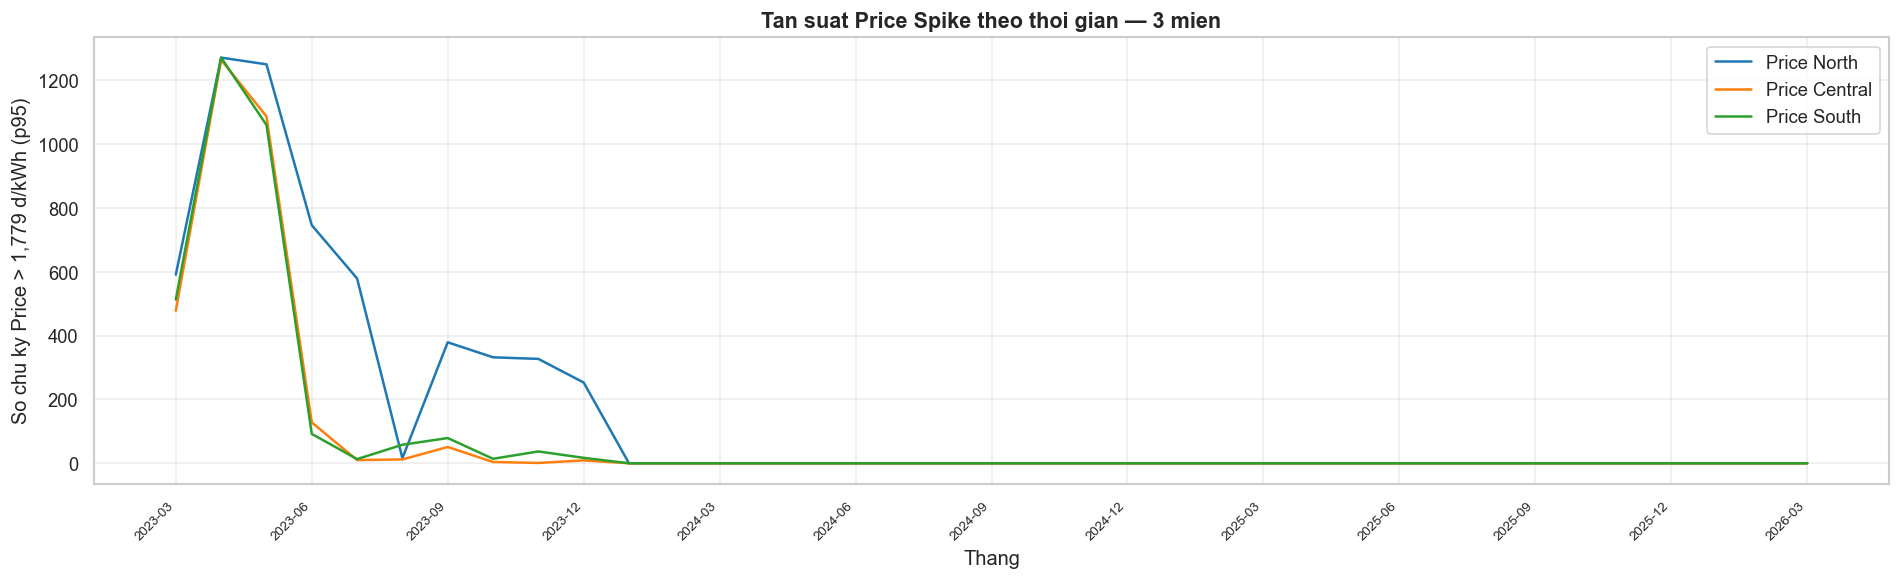

  -> Saved: price_spike_timeline.png

Price_North: Top 3 thang spike — [Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-06', 'M')] ([np.int64(1271), np.int64(1250), np.int64(746)] chu ky)
Price_Central: Top 3 thang spike — [Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-03', 'M')] ([np.int64(1264), np.int64(1087), np.int64(478)] chu ky)
Price_South: Top 3 thang spike — [Period('2023-04', 'M'), Period('2023-05', 'M'), Period('2023-03', 'M')] ([np.int64(1271), np.int64(1060), np.int64(513)] chu ky)


In [15]:
price_max = df[PRICE_COLS[:3]].max().max()
price_p95 = df[PRICE_COLS[:3]].quantile(0.95).max()
price_p99 = df[PRICE_COLS[:3]].quantile(0.99).max()

print(f'Price max : {price_max:,.0f} d/kWh')
print(f'Price p95 : {price_p95:,.0f} d/kWh')
print(f'Price p99 : {price_p99:,.0f} d/kWh')

# Dùng p95 trung bình 3 miền làm ngưỡng spike — top 5% cao nhất
SPIKE_THRESHOLD = float(df[PRICE_COLS[:3]].quantile(0.95).mean())
print(f'\n  -> SPIKE_THRESHOLD tu dong: {SPIKE_THRESHOLD:,.0f} d/kWh (p95 trung binh 3 mien)')

monthly_spike = (
    (df[PRICE_COLS[:3]] > SPIKE_THRESHOLD)
    .groupby(df.index.to_period('M'))
    .sum()
)

fig, ax = plt.subplots(figsize=(16, 5))
for col, color in zip(PRICE_COLS[:3], COLORS_3):
    ax.plot(
        range(len(monthly_spike)),
        monthly_spike[col],
        lw=1.5, color=color,
        label=col.replace('_', ' '),
    )

tick_step   = 3
tick_pos    = range(0, len(monthly_spike), tick_step)
tick_labels = [str(monthly_spike.index[i]) for i in tick_pos]
ax.set_xticks(list(tick_pos))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Thang')
ax.set_ylabel(f'So chu ky Price > {SPIKE_THRESHOLD:,.0f} d/kWh (p95)')
ax.set_title('Tan suat Price Spike theo thoi gian — 3 mien', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(str(REPORT_DIR / 'price_spike_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('  -> Saved: price_spike_timeline.png')

print()
for col in PRICE_COLS[:3]:
    top_month = monthly_spike[col].nlargest(3)
    print(f'{col}: Top 3 thang spike — {list(top_month.index)} ({list(top_month.values)} chu ky)')


**Nhận xét:**
- Spike Price thường tập trung vào **mùa khô** (tháng 4–7) khi thủy điện thiếu nước và nhu cầu điều hòa cao.
- Phân bố spike khác nhau giữa 3 miền → phản ánh cấu trúc nguồn điện và cơ chế khớp lệnh VCGM từng miền.

> **Lưu ý quan trọng:** Price **KHÔNG được dùng làm feature** trong model dự báo Load vì **data leakage** —  
> Price và Load được xác định đồng thời trong cùng chu kỳ khớp lệnh thị trường VCGM.  
> Price được phân tích ở đây như một chỉ số độc lập phản ánh trạng thái căng thẳng của hệ thống điện.


---
## 6. Tổng Kết EDA & Kết Luận

### Về dataset
- **Tổng:** 52,607 chu kỳ 30 phút × 3 năm (2023-03-11 00:30 → 2026-03-10 23:30)
- **Missing sau xử lý:** 0 — imputation hoàn tất, không làm lệch phân phối đáng kể
- **Outlier:** Phát hiện bằng IQR, ghi nhận vào `cleaning_summary.json`, không xóa  
  (outlier intrinsic — phản ánh sự kiện thực tế như sóng nhiệt, ngày lễ lớn)

### Về bài toán STLF
- **Target:** Load_North, Load_Central, Load_South (3 model độc lập)
- **Load_National:** Validation tổng hợp (so sánh ∑3 miền vs National thực tế)
- **Price:** KHÔNG dùng làm feature (data leakage), phân tích độc lập

### Justify Feature Engineering

| Feature | Bằng chứng từ EDA |
|---|---|
| `hour` | Daily pattern rõ ràng, biên độ peak–trough đáng kể |
| `is_peak` | 2 đỉnh cao điểm (sáng & chiều) hiện rõ trong daily pattern |
| `is_weekend` | Phụ tải cuối tuần thấp hơn ngày thường có ý nghĩa thực tế |
| `is_holiday` | Ngày lễ thấp hơn ngày thường rõ rệt |
| `month` | Seasonal variation rõ ràng, Bắc có biên độ mùa vụ lớn nhất |
| `temp` | R²(poly2) > R²(linear) → tính phi tuyến xác nhận, hình chữ U |
| `lag_t48` | Daily pattern ổn định → cùng giờ hôm qua là predictor tốt |

### Tại sao cần 3 model độc lập
- Quy mô phụ tải tuyệt đối khác nhau (Trung << Bắc ≈ Nam)
- Biên độ mùa vụ khác nhau (Bắc > Nam > Trung)
- Pattern tương quan với nhiệt độ khác nhau (Bắc: hình U rõ; Nam: ít biến thiên)
- CV% và IQR khác nhau đủ lớn → 1 model chung sẽ bias về miền dominant


---
## 7. Export eda_report.md

In [16]:
load_stats_str    = load_stats[display_cols].round(2).to_string()
price_stats_str   = price_stats[display_p].round(2).to_string()
comparison_str    = comparison.to_string()
summary_3mien_str = summary.round(1).to_string()

r2_rows = ''
for region, vals in r2_results.items():
    imp = (vals['r2_poly2'] - vals['r2_linear']) / vals['r2_linear'] * 100
    r2_rows += (
        f"| {REGION_MAP[region]} | {vals['r2_linear']:.3f} "
        f"| {vals['r2_poly2']:.3f} | +{imp:.1f}% |\n"
    )

report_lines = [
    '# EDA Report — DS108 NB07\n',
    '**Nhom:** La Gia Han (24520448) . Huynh Gia Hao (24520457)\n',
    '**Moc:** 2023-03-11 00:30 -> 2026-03-10 23:30\n\n',
    '---\n\n',
    '## 1. Thong ke mo ta\n\n',
    '### Load (MW)\n',
    load_stats_str, '\n\n',
    '### Price (d/kWh)\n',
    price_stats_str, '\n\n',
    '### So sanh truoc/sau xu ly\n',
    comparison_str, '\n\n',
    '---\n\n',
    '## 2. Phan phoi (Univariate)\n',
    '- Load: co the bimodal, skewness duong\n',
    '- Price: lech phai manh -> justify Z-score scaling\n\n',
    '---\n\n',
    '## 3. Tuong quan Load-Temperature\n',
    '| Mien | R2(linear) | R2(poly2) | Cai thien |\n',
    '|---|---|---|---|\n',
    r2_rows, '\n',
    '---\n\n',
    '## 4. Time Series Patterns\n',
    '- Daily: 2 dinh cao diem sang & chieu -> justify hour, is_peak\n',
    '- Weekly: ngay thuong > cuoi tuan -> justify is_weekend\n',
    '- Seasonal: Bac bien do lon nhat -> justify month\n',
    '- Holiday: ngay le thap hon ro ret -> justify is_holiday\n\n',
    '---\n\n',
    '## 5. So sanh 3 mien\n',
    summary_3mien_str, '\n\n',
    '---\n\n',
    '## 6. Bieu do da luu (reports/eda_after/)\n',
    '- hist_load.png . hist_price.png\n',
    '- scatter_load_temp.png . heatmap_load_features.png\n',
    '- daily_pattern.png . weekly_pattern.png . seasonal_pattern.png\n',
    '- holiday_effect.png . boxplot_3mien.png . price_spike_timeline.png\n',
]

report_path = Path('reports') / 'eda_report.md'
report_path.parent.mkdir(parents=True, exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(''.join(report_lines))
print(f'  -> Saved: {report_path}')

print()
print('=== NB07 hoan thanh — Checklist ===')
checklist = [
    'hist_load.png',
    'hist_price.png',
    'scatter_load_temp.png',
    'heatmap_load_features.png',
    'daily_pattern.png',
    'weekly_pattern.png',
    'seasonal_pattern.png',
    'holiday_effect.png',
    'boxplot_3mien.png',
    'price_spike_timeline.png',
]
for fname in checklist:
    status = '[OK]' if (REPORT_DIR / fname).exists() else '[MISSING]'
    print(f'  {status}  {fname}')


  -> Saved: reports\eda_report.md

=== NB07 hoan thanh — Checklist ===
  [OK]  hist_load.png
  [OK]  hist_price.png
  [OK]  scatter_load_temp.png
  [OK]  heatmap_load_features.png
  [OK]  daily_pattern.png
  [OK]  weekly_pattern.png
  [OK]  seasonal_pattern.png
  [OK]  holiday_effect.png
  [OK]  boxplot_3mien.png
  [OK]  price_spike_timeline.png
